# PROJET 5A - Modélisation Baseline : Régression Logistique

**Objectif :** Établir la performance de référence (Baseline) et valider les facteurs explicatifs.

**Pourquoi la Régression Logistique ?**
Avant de lancer des modèles complexes (XGBoost), nous devons tester la linéarité du problème. Si la RL fait aussi bien que le marché, alors le problème est "résolu" par les cotes.

**Protocole Scientifique :**
1.  **Données :** Dataset `Select_Championnats` (Données complètes post-2005).
2.  **Validation :** `TimeSeriesSplit` (5 blocs) pour respecter la temporalité.
3.  **Benchmark :** Comparaison systématique avec l'accuracy des Bookmakers (Cote min).
4.  **Contrainte :** Suppression d'une variable de cote (`ImpProb_Away`) pour éviter la multicolinéarité parfaite ($P_H + P_D + P_A = 1$).

### Imports et Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss

# Gestion des chemins
sys.path.append(os.getcwd())
try:
    import config as cfg
    print(f"Config chargée, source : {cfg.FILE_SELECT}")
except ImportError:
    print("Config introuvable")

sns.set_theme(style="whitegrid")

Config chargée, source : C:\Users\Alban\Documents\IMDS\Projet_5A\Donnees\matches_select_championnats.csv


In [17]:
# Chargement
df = pd.read_csv(cfg.FILE_SELECT, sep=";", parse_dates=["MatchDate"], dayfirst=True)
df = df.sort_values("MatchDate").reset_index(drop=True)

# Target Encoding
target_map = {'H': 0, 'D': 1, 'A': 2}
df["Target"] = df["FTResult"].map(target_map)

# Création des Probas Implicites 
# On normalise pour que somme = 1 
probs_sum = (1/df["OddHome"]) + (1/df["OddDraw"]) + (1/df["OddAway"])
df["ImpProb_Home"] = (1/df["OddHome"]) / probs_sum
df["ImpProb_Draw"] = (1/df["OddDraw"]) / probs_sum
# Note : On ne crée PAS ImpProb_Away pour le modèle 
df["ImpProb_Away"] = (1/df["OddAway"]) / probs_sum

# Sélection des Features
features = [
    "EloDiff", 
    "Form5Diff", 
    "ImpProb_Home", 
    "ImpProb_Draw"
]

# Nettoyage final 
cols_needed = features + ["Target", "OddHome", "OddDraw", "OddAway"]
df_model = df[cols_needed].replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

print(f"Données : {df_model.shape}")
print(f"Features : {features}")

Données : (47369, 8)
Features : ['EloDiff', 'Form5Diff', 'ImpProb_Home', 'ImpProb_Draw']


### Inférence (Comprendre le poids des variables)

In [18]:
print("ANALYSE INFÉRENCE (Statsmodels) ")

# (Z-Score) pour compareaison les coefficients
scaler_stat = StandardScaler()
X_stat = pd.DataFrame(scaler_stat.fit_transform(df_model[features]), columns=features)
y_stat = df_model["Target"]

# Ajout constante
X_stat = sm.add_constant(X_stat)

# Modèle Multinomial
model_stat = sm.MNLogit(y_stat, X_stat)
result_stat = model_stat.fit(disp=0)

print(result_stat.summary())

ANALYSE INFÉRENCE (Statsmodels) 
                          MNLogit Regression Results                          
Dep. Variable:                 Target   No. Observations:                47369
Model:                        MNLogit   Df Residuals:                    47359
Method:                           MLE   Df Model:                            8
Date:                Fri, 12 Dec 2025   Pseudo R-squ.:                 0.07596
Time:                        17:10:05   Log-Likelihood:                -46836.
converged:                       True   LL-Null:                       -50686.
Covariance Type:            nonrobust   LLR p-value:                     0.000
    Target=1       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.4818      0.012    -40.278      0.000      -0.505      -0.458
EloDiff         -0.0392      0.029     -1.344      0.179      -0.096       0.018
Form5Diff  

### INTERPRÉTATION 
- Si P>|z| est < 0.05, la variable est significative
- Regardez 'ImpProb_Draw' : est-ce qu'elle aide vraiment à prédire le Nul (1) ?

### Backtesting

In [19]:
tscv = TimeSeriesSplit(n_splits=5)
model_sk = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=2000)

metrics = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(df_model)):
    # Split
    X_train, X_test = df_model.loc[train_idx, features], df_model.loc[test_idx, features]
    y_train, y_test = df_model.loc[train_idx, "Target"], df_model.loc[test_idx, "Target"]
    
    # Scaling 
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    # Entraînement
    model_sk.fit(X_train_s, y_train)
    y_pred = model_sk.predict(X_test_s)
    y_prob = model_sk.predict_proba(X_test_s)
    
    # Benchmark Marché 
    odds_test = df_model.loc[test_idx, ["OddHome", "OddDraw", "OddAway"]]
    market_pred = odds_test.idxmin(axis=1).map({"OddHome": 0, "OddDraw": 1, "OddAway": 2})
    
    # Métriques
    acc_model = accuracy_score(y_test, y_pred)
    acc_market = accuracy_score(y_test, market_pred)
    loss = log_loss(y_test, y_prob)
    
    metrics.append({
        "Fold": fold + 1,
        "Train_Size": len(X_train),
        "Test_Size": len(X_test),
        "Acc_Model": acc_model,
        "Acc_Market": acc_market,
        "Delta": acc_model - acc_market,
        "LogLoss": loss
    })
    
    print(f"Fold {fold+1}: Modèle {acc_model:.2%} vs Marché {acc_market:.2%} (Delta: {acc_model-acc_market:+.2%})")

res_df = pd.DataFrame(metrics)
print("\nRÉSULTATS GLOBAUX")
print(f"Accuracy Moyenne Modèle : {res_df['Acc_Model'].mean():.2%}")
print(f"Accuracy Moyenne Marché : {res_df['Acc_Market'].mean():.2%}")

Fold 1: Modèle 51.44% vs Marché 51.39% (Delta: +0.05%)
Fold 2: Modèle 52.70% vs Marché 52.65% (Delta: +0.05%)
Fold 3: Modèle 51.37% vs Marché 51.41% (Delta: -0.04%)
Fold 4: Modèle 51.49% vs Marché 51.53% (Delta: -0.04%)


c:\Users\Alban\Documents\IMDS\Projet_5A\Projet_5A_Prediction_matchs\.venv_pred_match\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Alban\Documents\IMDS\Projet_5A\Projet_5A_Prediction_matchs\.venv_pred_match\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Alban\Documents\IMDS\Projet_5A\Projet_5A_Prediction_matchs\.venv_pred_match\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default va

Fold 5: Modèle 52.74% vs Marché 52.76% (Delta: -0.03%)

RÉSULTATS GLOBAUX
Accuracy Moyenne Modèle : 51.95%
Accuracy Moyenne Marché : 51.95%


### Analyse des Erreurs (Matrice)

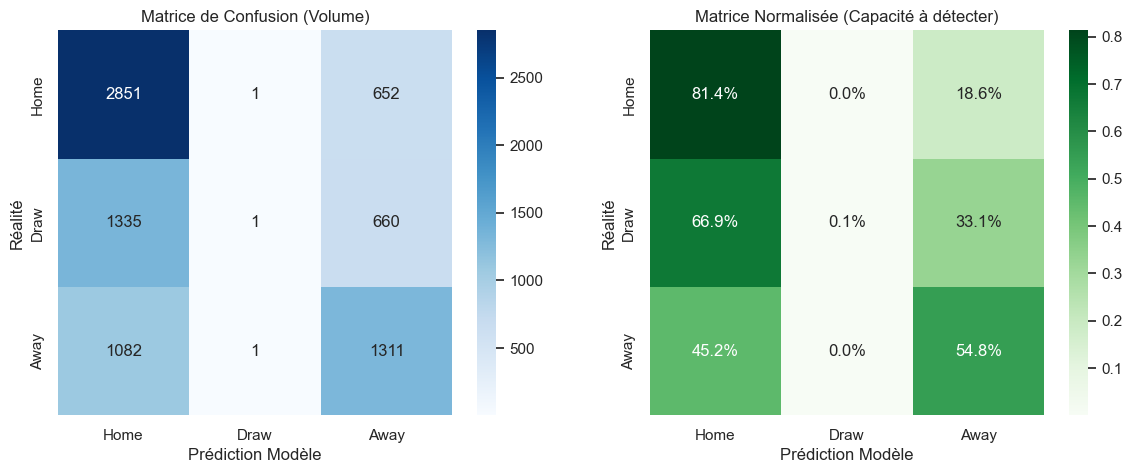

Analyse du Nul :
Il y avait 1996 matchs nuls réels
Le modèle en a prédit 3


In [20]:
# Analyse sur le dernier Fold 
labels = ["Home", "Draw", "Away"]
cm = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true') # Normalisé par ligne (Réalité)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Volume
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[0], xticklabels=labels, yticklabels=labels)
ax[0].set_title("Matrice de Confusion (Volume)")
ax[0].set_ylabel("Réalité")
ax[0].set_xlabel("Prédiction Modèle")

# Pourcentage 
sns.heatmap(cm_norm, annot=True, fmt=".1%", cmap="Greens", ax=ax[1], xticklabels=labels, yticklabels=labels)
ax[1].set_title("Matrice Normalisée (Capacité à détecter)")
ax[1].set_ylabel("Réalité")
ax[1].set_xlabel("Prédiction Modèle")

plt.show()

print("Analyse du Nul :")
nb_nuls_reels = np.sum(y_test == 1)
nb_nuls_predits = np.sum(y_pred == 1)
print(f"Il y avait {nb_nuls_reels} matchs nuls réels")
print(f"Le modèle en a prédit {nb_nuls_predits}")

### Conclusion et Diagnostic Final (Baseline RL)

#### 1. Performance vs Baseline (Le verdict)
* **Accuracy Modèle (Moyenne 5 folds) :** 51.95%
* **Accuracy Marché (Cotes) :** 51.95%
* **Écart :** **0.00%** (Strictement identique)

**Interprétation :** La Régression Logistique n'apporte **aucune valeur ajoutée** par rapport à une stratégie naïve consistant à suivre le favori des bookmakers. Cela démontre que les cotes intègrent déjà parfaitement toute l'information *linéaire* disponible (Elo, Forme).

#### 2. Le "Mur" du Match Nul (Biais Structurel)
Le diagnostic est sans appel :
* **Nuls Réels (Réalité) :** 1 996 matchs (sur le dernier fold).
* **Nuls Prédits (Modèle) :** 3 matchs.
* **Taux de Détection :** **0.15%** (Quasi-nul).

**Pourquoi ?** Le modèle linéaire cherche à maximiser son accuracy globale. Comme la probabilité d'un nul dépasse rarement 30% (contrairement à une victoire domicile qui peut atteindre 60-70%), l'algorithme "sacrifie" mathématiquement la classe Nul pour ne pas prendre de risque. C'est la limite fondamentale de l'approche linéaire.

#### 3. Analyse des Facteurs (P-values)
L'analyse d'inférence (Statsmodels) confirme la hiérarchie de l'information :
* **Dominance des Cotes :** Les variables `ImpProb_Home` et `ImpProb_Draw` ont des z-scores massifs (P < 0.001). Ce sont les seuls vrais moteurs de la décision.
* **Redondance du Elo :** Une fois les cotes incluses, la variable `EloDiff` n'est plus significative pour prédire la victoire domicile (P > 0.1). L'information du Elo est déjà "mangée" par les cotes.

#### Décision Stratégique : Transition vers XGBoost
Nous avons atteint le "plafond de verre" de la linéarité. Pour battre le marché, nous devons absolument **débloquer la prédiction des matchs nuls**.
La prochaine étape (Notebook `Modélisation_XGB_RF`) visera à utiliser des modèles non-linéaires (Arbres de décision) capables d'isoler des poches de rentabilité spécifiques (ex: "Matchs serrés où l'outsider est en forme") que la RL ne peut pas voir.